# Chromatin Figures

Regenerate chromatin `plotProfile` and `plotHeatmap` outputs from the saved deepTools matrices written by `analysis/03_chromatin_analysis/run_chromatin.py`.


In [1]:
%load_ext autoreload
%autoreload 2

import shutil
import subprocess
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from utils.figures_utils import RESULTS_DIR


In [2]:
OUT_DIR = Path("out") / "chromatin_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True
SELECTED_SAMPLES = None

CHROMATIN_RESULTS_DIR = RESULTS_DIR / "03_chromatin_analysis"
DEEPTOOLS_OUTPUTS_PATH = CHROMATIN_RESULTS_DIR / "tables" / "deeptools_outputs.tsv"
DEEPTOOLS_REGION_MANIFEST_PATH = CHROMATIN_RESULTS_DIR / "tables" / "deeptools_region_manifest.tsv"
EXPECTED_ENV_BIN = Path(
    "/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/env/jt_wgbs_analysis/bin"
)


In [3]:
def ensure_deeptools_commands() -> tuple[str, str]:
    plot_profile = shutil.which("plotProfile")
    plot_heatmap = shutil.which("plotHeatmap")
    missing = []
    if plot_profile is None:
        missing.append("plotProfile")
    if plot_heatmap is None:
        missing.append("plotHeatmap")
    if missing:
        expected_msg = ""
        if EXPECTED_ENV_BIN.exists():
            expected_msg = (
                f" Expected them on PATH from jt_wgbs_analysis, for example under {EXPECTED_ENV_BIN}."
            )
        raise RuntimeError(
            "Missing deepTools command(s): " + ", ".join(missing) + "."
            + " Start the notebook from the jt_wgbs_analysis environment."
            + expected_msg
        )
    return plot_profile, plot_heatmap


def load_deeptools_outputs_df() -> pd.DataFrame:
    outputs_df = pd.read_csv(DEEPTOOLS_OUTPUTS_PATH, sep="\t")
    outputs_df = outputs_df.sort_values("sample").reset_index(drop=True)
    return outputs_df


def load_region_manifest_df() -> pd.DataFrame:
    region_df = pd.read_csv(DEEPTOOLS_REGION_MANIFEST_PATH, sep="\t")
    region_df = region_df.sort_values(["sample", "deeptools_order", "tool"]).reset_index(drop=True)
    return region_df


def select_outputs_row(outputs_df: pd.DataFrame, sample: str) -> pd.Series:
    sample_rows = outputs_df.loc[outputs_df["sample"].eq(sample)]
    if sample_rows.empty:
        raise KeyError(f"Sample not present in deepTools outputs manifest: {sample}")
    if len(sample_rows) != 1:
        raise ValueError(f"Expected exactly one deepTools outputs row for {sample}, found {len(sample_rows)}")
    return sample_rows.iloc[0]


def resolve_saved_matrix_path(outputs_row: pd.Series) -> Path:
    matrix_path = Path(outputs_row["matrix_path"]).expanduser()
    if matrix_path.exists():
        return matrix_path

    sample = str(outputs_row["sample"])
    fallback_path = CHROMATIN_RESULTS_DIR / "deeptools" / sample / matrix_path.name
    if fallback_path.exists():
        return fallback_path

    raise FileNotFoundError(
        f"Saved deepTools matrix not found for {sample}. Tried {matrix_path} and {fallback_path}."
    )


def get_region_labels_for_sample(region_df: pd.DataFrame, sample: str) -> list[str]:
    sample_region_df = region_df.loc[region_df["sample"].eq(sample)].copy()
    if sample_region_df.empty:
        raise KeyError(f"Sample not present in deepTools region manifest: {sample}")
    sample_region_df = sample_region_df.sort_values(["deeptools_order", "tool"]).reset_index(drop=True)
    return sample_region_df["tool_label"].astype(str).tolist()


def run_command(command: list[str]) -> None:
    print(" ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {' '.join(command)}")
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)


def output_paths_for_sample(sample: str) -> tuple[Path, Path]:
    profile_out = OUT_DIR / f"{sample}.h3k36me2.profile.png"
    heatmap_out = OUT_DIR / f"{sample}.h3k36me2.heatmap.png"
    return profile_out, heatmap_out


def regenerate_sample_plots(
    outputs_row: pd.Series,
    region_df: pd.DataFrame,
    plot_profile_cmd: str,
    plot_heatmap_cmd: str,
) -> dict:
    sample = str(outputs_row["sample"])
    sample_id = str(outputs_row["sample_id"])
    matrix_path = resolve_saved_matrix_path(outputs_row)
    region_labels = get_region_labels_for_sample(region_df, sample)
    profile_out, heatmap_out = output_paths_for_sample(sample)

    profile_command = [
        plot_profile_cmd,
        "--numPlotsPerRow",
        "3",
        "-m",
        str(matrix_path),
        "--perGroup",
        "--samplesLabel",
        sample_id,
        "--regionsLabel",
        *region_labels,
        "--startLabel",
        "Region start",
        "--endLabel",
        "Region end",
        "--plotTitle",
        f"{sample} H3K36me2 profile across tool-derived regions",
        "-out",
        str(profile_out),
    ]

    heatmap_command = [
        plot_heatmap_cmd,
        "-m",
        str(matrix_path),
        "--samplesLabel",
        sample_id,
        "--regionsLabel",
        *region_labels,
        "--startLabel",
        "Region start",
        "--endLabel",
        "Region end",
        "--plotTitle",
        f"{sample} H3K36me2 heatmap across tool-derived regions",
        "--sortRegions",
        "keep",
        "--heatmapWidth",
        "14",
        "--heatmapHeight",
        "12",
        "--whatToShow",
        "heatmap and colorbar",
        "-out",
        str(heatmap_out),
    ]

    run_command(profile_command)
    run_command(heatmap_command)

    if not profile_out.exists():
        raise FileNotFoundError(f"plotProfile did not create expected file: {profile_out}")
    if not heatmap_out.exists():
        raise FileNotFoundError(f"plotHeatmap did not create expected file: {heatmap_out}")

    return {
        "sample": sample,
        "sample_id": sample_id,
        "matrix_path": str(matrix_path),
        "profile_png": str(profile_out),
        "heatmap_png": str(heatmap_out),
        "region_labels": region_labels,
    }


def display_sample_plots(plot_info: dict) -> None:
    display(Markdown(f"## {plot_info['sample']}"))
    display(Markdown(f"Matrix: `{plot_info['matrix_path']}`"))
    display(Image(filename=plot_info["profile_png"]))
    display(Image(filename=plot_info["heatmap_png"]))


In [4]:
plot_profile_cmd, plot_heatmap_cmd = ensure_deeptools_commands()
deeptools_outputs_df = load_deeptools_outputs_df()
deeptools_region_df = load_region_manifest_df()

if SELECTED_SAMPLES is None:
    samples_to_plot = deeptools_outputs_df["sample"].astype(str).tolist()
else:
    samples_to_plot = [sample for sample in SELECTED_SAMPLES if sample in set(deeptools_outputs_df["sample"].astype(str))]

display(deeptools_outputs_df[["sample", "sample_id", "matrix_path", "profile_path", "heatmap_path"]])
display(deeptools_region_df[["sample", "tool_label", "deeptools_order", "visualized_regions"]])
print("Samples to plot:", samples_to_plot)


,sample,sample_id,matrix_path,profile_path,heatmap_path
0,ESO26.wgbs,ESO26,/scratch/general/vast/u0914269/methylseg_resul...,/scratch/general/vast/u0914269/methylseg_resul...,NaN
1,TE5.wgbs,TE5,/scratch/general/vast/u0914269/methylseg_resul...,/scratch/general/vast/u0914269/methylseg_resul...,NaN


,sample,tool_label,deeptools_order,visualized_regions
0,ESO26.wgbs,MethylSeg WGBS,0,1334
1,ESO26.wgbs,MethylSeg HM450K,1,1026
2,ESO26.wgbs,MethylSeekR,2,10551
3,ESO26.wgbs,DNMTools,3,3472
4,ESO26.wgbs,DNMTools Array,4,69
5,ESO26.wgbs,DNMTools PMR,5,23253
6,ESO26.wgbs,MMSeekR,6,3738
7,ESO26.wgbs,MethylLasso,7,7672
8,TE5.wgbs,MethylSeg WGBS,0,1810
9,TE5.wgbs,MethylSeg HM450K,1,1518


Samples to plot: ['ESO26.wgbs', 'TE5.wgbs']


/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/env/jt_wgbs_analysis/bin/plotProfile --numPlotsPerRow 3 -m /scratch/general/vast/u0914269/methylseg_results/03_chromatin_analysis/deeptools/ESO26.wgbs/ESO26.wgbs.h3k36me2.matrix.gz --perGroup --samplesLabel ESO26 --regionsLabel MethylSeg WGBS MethylSeg HM450K MethylSeekR DNMTools DNMTools Array DNMTools PMR MMSeekR MethylLasso --startLabel Region start --endLabel Region end --plotTitle ESO26.wgbs H3K36me2 profile across tool-derived regions -out out/chromatin_figures/ESO26.wgbs.h3k36me2.profile.png

/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/env/jt_wgbs_analysis/bin/plotHeatmap -m /scratch/general/vast/u0914269/methylseg_results/03_chromatin_analysis/deeptools/ESO26.wgbs/ESO26.wgbs.h3k36me2.matrix.gz --samplesLabel ESO26 --regionsLabel MethylSeg WGBS MethylSeg HM450K MethylSeekR DNMTools DNMTools Array DNMTools PMR MMSeekR MethylLasso --startLabel Region start --endLabel Region end --plotTitle ESO26.

## ESO26.wgbs

Matrix: `/scratch/general/vast/u0914269/methylseg_results/03_chromatin_analysis/deeptools/ESO26.wgbs/ESO26.wgbs.h3k36me2.matrix.gz`

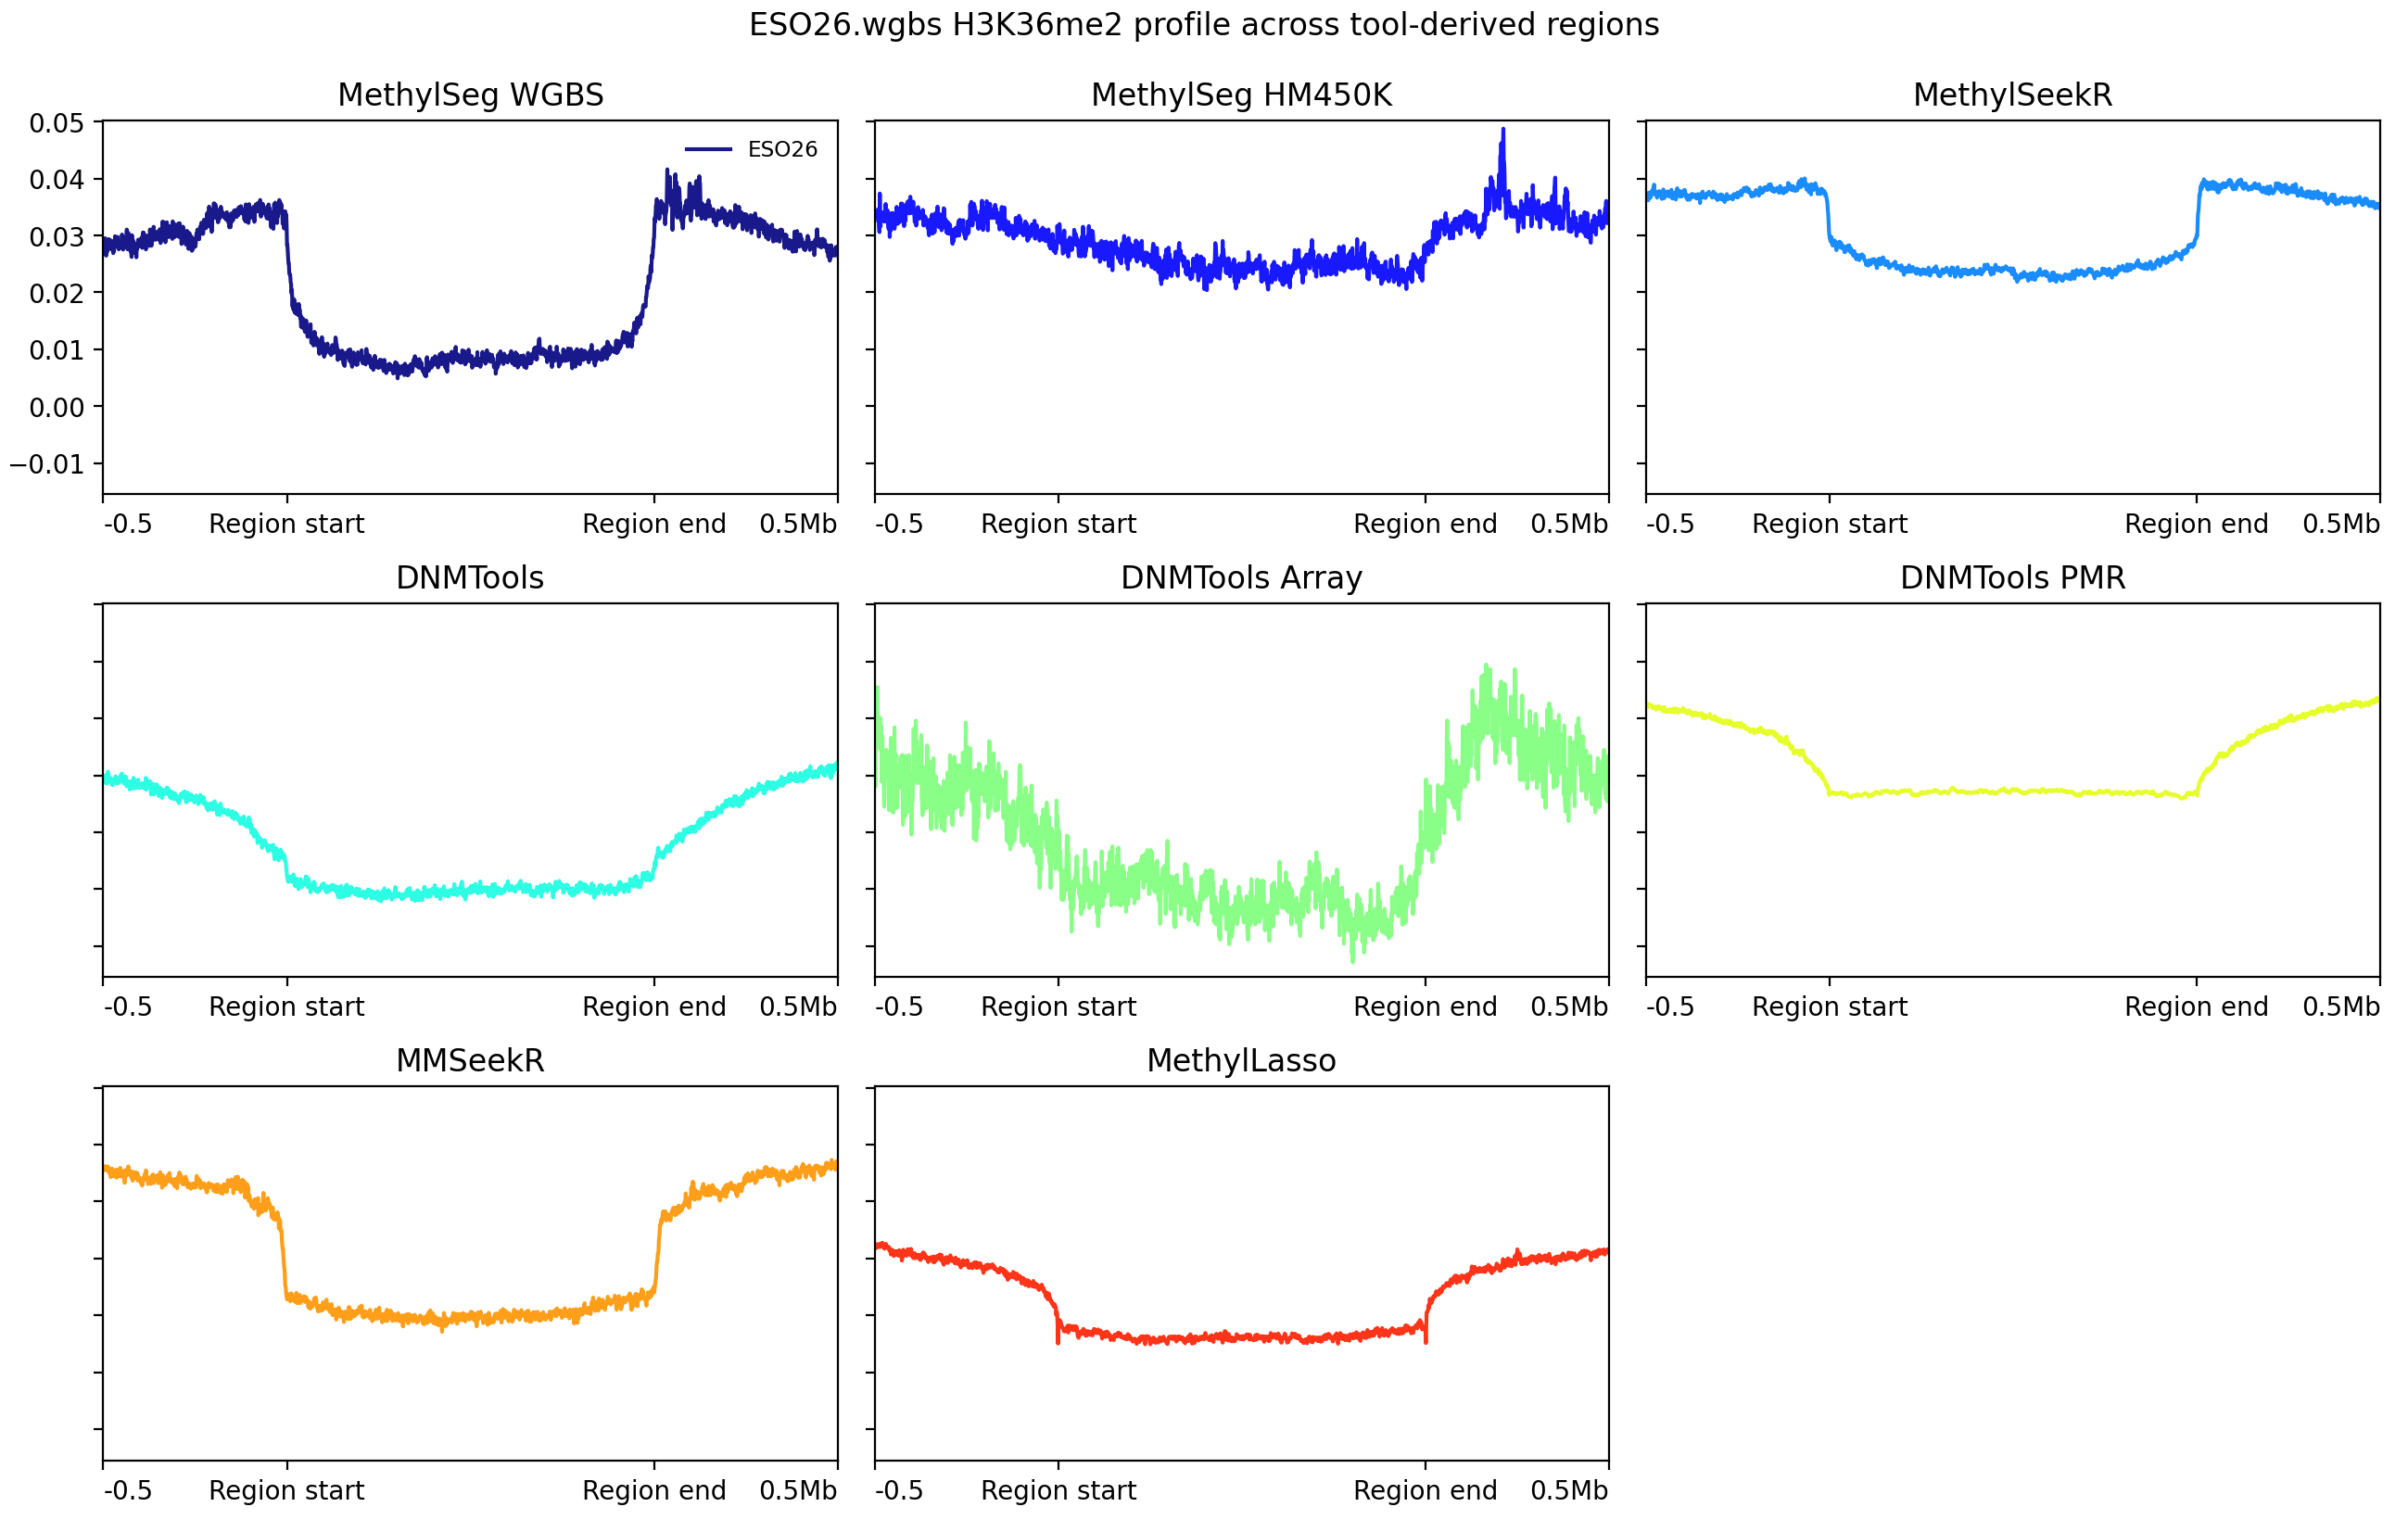

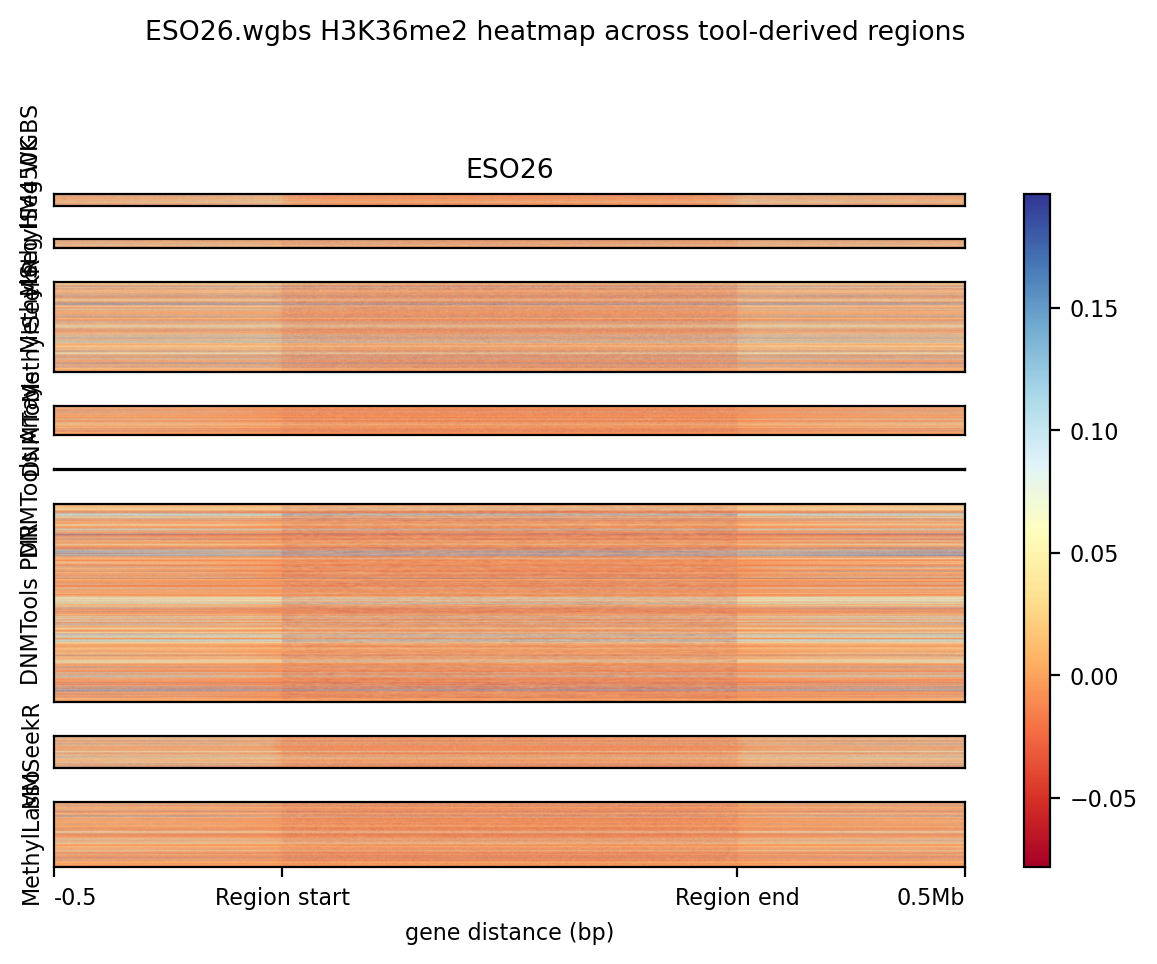

/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/env/jt_wgbs_analysis/bin/plotProfile --numPlotsPerRow 3 -m /scratch/general/vast/u0914269/methylseg_results/03_chromatin_analysis/deeptools/TE5.wgbs/TE5.wgbs.h3k36me2.matrix.gz --perGroup --samplesLabel TE5 --regionsLabel MethylSeg WGBS MethylSeg HM450K MethylSeekR DNMTools DNMTools Array DNMTools PMR MMSeekR MethylLasso --startLabel Region start --endLabel Region end --plotTitle TE5.wgbs H3K36me2 profile across tool-derived regions -out out/chromatin_figures/TE5.wgbs.h3k36me2.profile.png

/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/env/jt_wgbs_analysis/bin/plotHeatmap -m /scratch/general/vast/u0914269/methylseg_results/03_chromatin_analysis/deeptools/TE5.wgbs/TE5.wgbs.h3k36me2.matrix.gz --samplesLabel TE5 --regionsLabel MethylSeg WGBS MethylSeg HM450K MethylSeekR DNMTools DNMTools Array DNMTools PMR MMSeekR MethylLasso --startLabel Region start --endLabel Region end --plotTitle TE5.wgbs H3K36me2 heat

## TE5.wgbs

Matrix: `/scratch/general/vast/u0914269/methylseg_results/03_chromatin_analysis/deeptools/TE5.wgbs/TE5.wgbs.h3k36me2.matrix.gz`

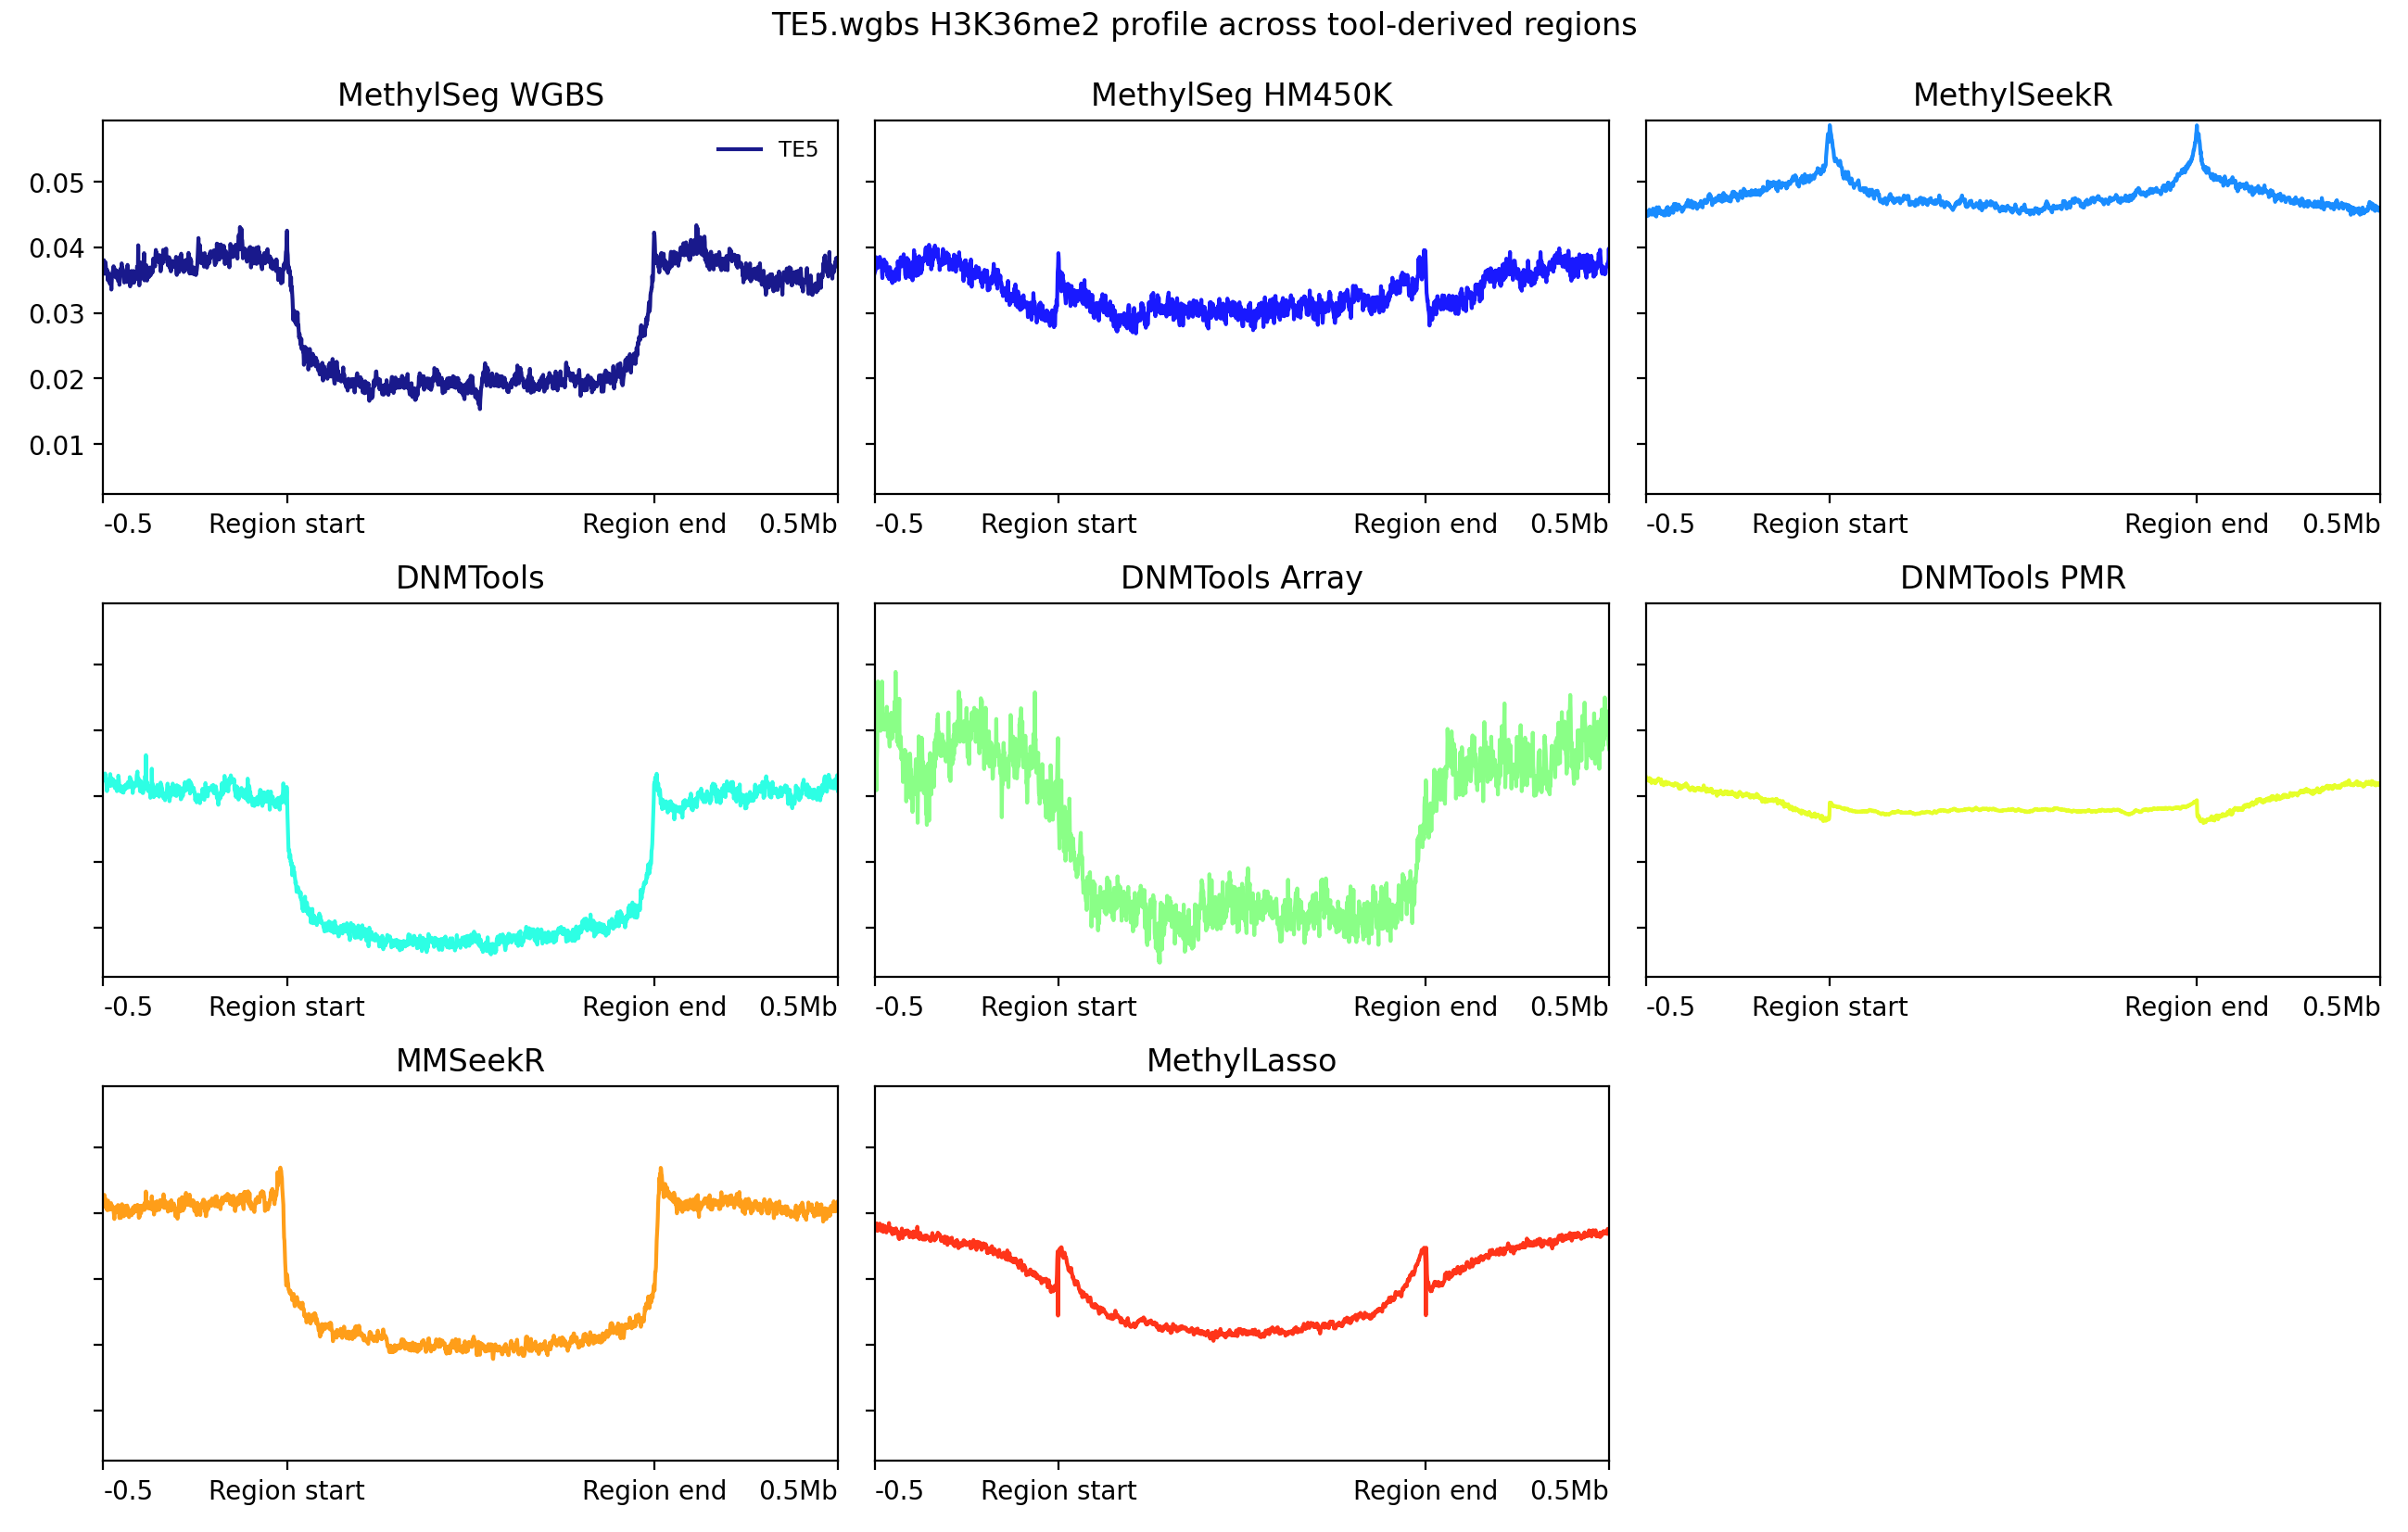

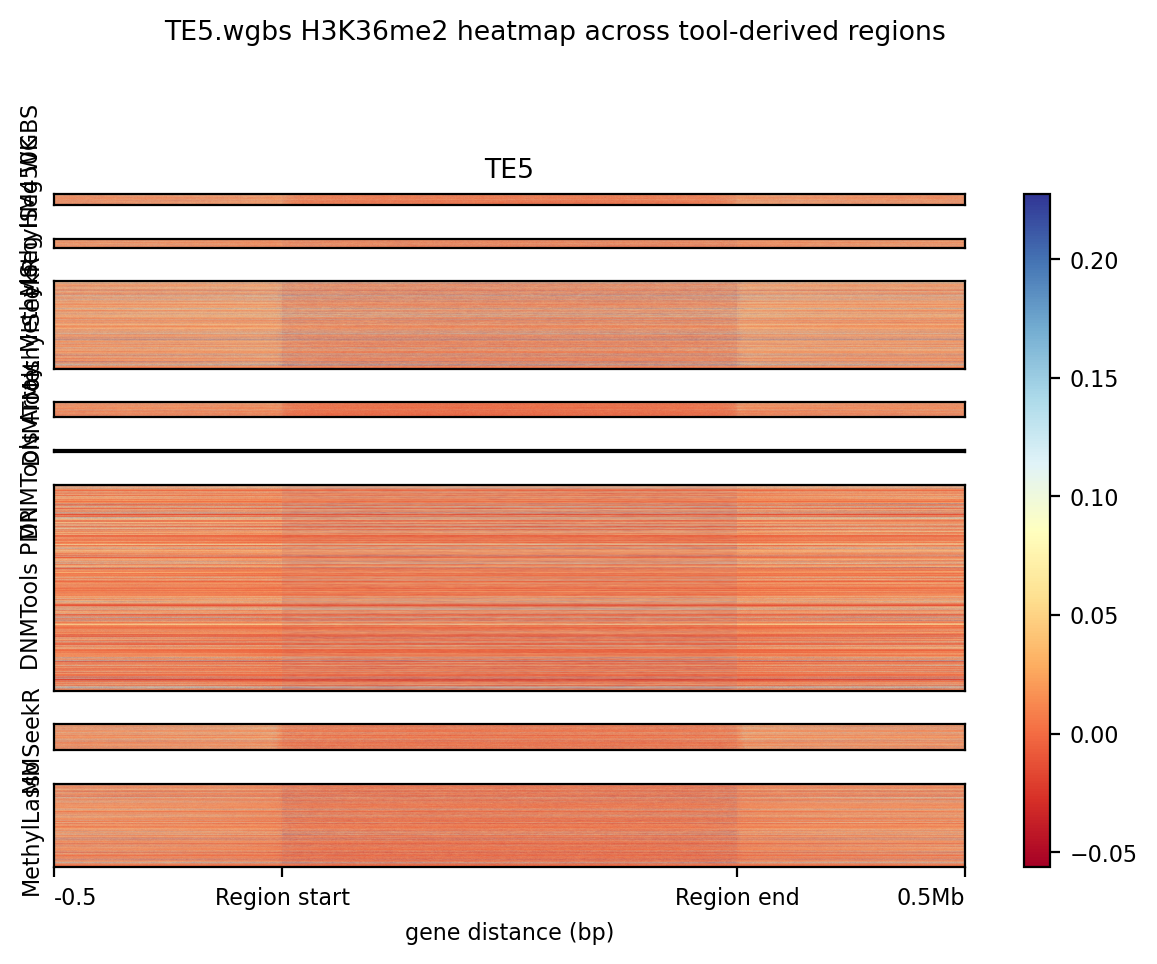

,sample,sample_id,matrix_path,profile_png,heatmap_png,region_labels
0,ESO26.wgbs,ESO26,/scratch/general/vast/u0914269/methylseg_resul...,out/chromatin_figures/ESO26.wgbs.h3k36me2.prof...,out/chromatin_figures/ESO26.wgbs.h3k36me2.heat...,"[MethylSeg WGBS, MethylSeg HM450K, MethylSeekR..."
1,TE5.wgbs,TE5,/scratch/general/vast/u0914269/methylseg_resul...,out/chromatin_figures/TE5.wgbs.h3k36me2.profil...,out/chromatin_figures/TE5.wgbs.h3k36me2.heatma...,"[MethylSeg WGBS, MethylSeg HM450K, MethylSeekR..."


In [5]:
generated_plot_rows = []

for sample in samples_to_plot:
    outputs_row = select_outputs_row(deeptools_outputs_df, sample)
    plot_info = regenerate_sample_plots(
        outputs_row=outputs_row,
        region_df=deeptools_region_df,
        plot_profile_cmd=plot_profile_cmd,
        plot_heatmap_cmd=plot_heatmap_cmd,
    )
    generated_plot_rows.append(plot_info)
    display_sample_plots(plot_info)

generated_plots_df = pd.DataFrame(generated_plot_rows)
generated_plots_df
